In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torchsummary

from torch import nn
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm, notebook

from sklearn.preprocessing import MinMaxScaler

In [ ]:
class CNNDiscriminator(nn.Module):
  def __init__(self):
    super().__init__()

    self.layers = nn.Sequential(
        nn.Linear(in_features=9, out_features=3), nn.BatchNorm1d(3), nn.LeakyReLU(), nn.Dropout(0.2),
        nn.Linear(in_features=3, out_features=1), nn.Sigmoid(),

    )

    self.bse = nn.BCELoss()

  def forward(self, x):
    x = self.layers(x)
    return x

  def loss(self, predicted, real):
    return self.bse(predicted, real)

class CNNGenerator(nn.Module):
  def __init__(self):
    super().__init__()

    self.generator = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(6, 1)), nn.LeakyReLU(),
        nn.Conv2d(in_channels=32, out_channels=16, kernel_size=(6, 1)), nn.LeakyReLU(),
        nn.Conv2d(in_channels=16, out_channels=8, kernel_size=(6, 1)), nn.LeakyReLU(),
        nn.Conv2d(in_channels=8, out_channels=4, kernel_size=(4, 1)), nn.LeakyReLU(),
        nn.Conv2d(in_channels=4, out_channels=2, kernel_size=(4, 1)), nn.LeakyReLU(),
        nn.Conv2d(in_channels=2, out_channels=1, kernel_size=(3, 1)), nn.LeakyReLU(),
    )
    self.bottleneck = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=9, out_features=3), nn.LeakyReLU(),
        nn.Linear(in_features=3, out_features=9), nn.Tanh(),
    )

    self.mse = nn.MSELoss()

  def forward(self, x):
    x = self.generator(x)
    x = self.bottleneck(x)
    return x

  def reconstruction_loss(self, real_sample, generated_sample):
    return self.mse(generated_sample, real_sample)

torchsummary.summary(CNNDiscriminator(), (9,))
torchsummary.summary(CNNGenerator(), (1, 24, 9))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 3]              30
       BatchNorm1d-2                    [-1, 3]               6
         LeakyReLU-3                    [-1, 3]               0
           Dropout-4                    [-1, 3]               0
            Linear-5                    [-1, 1]               4
           Sigmoid-6                    [-1, 1]               0
Total params: 40
Trainable params: 40
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 32, 19, 9]    

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, filepath : str):
    super().__init__()

    self.df = pd.read_csv(filepath).drop(["NOX", "CO"], axis=1)

    self.seq_len = 24
    self.data_height, self.data_width = self.df.shape

    self.scaler = MinMaxScaler(feature_range=(-1, 1))
    self.df_scaled = pd.DataFrame(self.scaler.fit_transform(self.df), columns=self.df.columns)

    self.df_tensor = self.__df_to_tensor()

  def __get_device(self):
    return torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

  def __df_to_tensor(self):
    return torch.from_numpy(self.df_scaled.values).float().to(self.__get_device())

  def __len__(self):
    return self.data_height

  def __getitem__(self, index):
    if index + self.seq_len >= self.data_height: raise StopIteration

    data = self.df_tensor[index:index+self.seq_len, :]
    label = self.df_tensor[index+self.seq_len, :]

    data = torch.unsqueeze(data, axis=0)

    return data, label


train_dataset = CustomDataset(filepath="sample_data/gt_2012.csv")
train_loader = DataLoader(train_dataset, batch_size=64)

for data, label in train_loader:
  print(data.shape, label.shape)
  break

torch.Size([64, 1, 24, 9]) torch.Size([64, 9])


In [ ]:
# torch.manual_seed(42)

# generator = CNNGenerator()

# lr = 1e-3
# use_lr_schedular = True
# num_epochs = 10

# optimizer_generator = torch.optim.SGD(generator.parameters(), lr=lr, momentum=0.94)
# lr_schedular_generator = lr_scheduler.LinearLR(
#                                                 optimizer=optimizer_generator,
#                                                 start_factor=1.0,
#                                                 end_factor=0.01 if use_lr_schedular else 1.0,
#                                                 total_iters=int(num_epochs * 0.7)
# )

# for epoch in range(1, num_epochs+1):

#   pbar = tqdm_notebook(enumerate(train_loader, 1), unit="Batch")
#   for n, (data, label) in pbar:
#     pbar.set_description(f"Epoch = {epoch:04d}")

#     generated_sample = generator(data)
#     # print(generated_sample.shape, label.shape)
#     reconstruction_loss = generator.reconstruction_loss(label, generated_sample)

#     generator.zero_grad()
#     reconstruction_loss.backward(retain_graph=True)
#     optimizer_generator.step()

#     pbar.set_postfix({"Loss":reconstruction_loss.detach().numpy()})
#     # break
#   lr_schedular_generator.step()
#   # break

In [ ]:
import copy

torch.manual_seed(42)

discriminator = CNNDiscriminator()
generator     = CNNGenerator()

lr = 1e-3
use_lr_schedular = True
num_epochs = 10

optimizer_discriminator = torch.optim.SGD(discriminator.parameters(), lr=lr, momentum=0.94)

optimizer_generator = torch.optim.SGD(generator.parameters(), lr=lr, momentum=0.94)
lr_schedular_generator = lr_scheduler.LinearLR(
                                                optimizer=optimizer_generator,
                                                start_factor=1.0,
                                                end_factor=0.01 if use_lr_schedular else 1.0,
                                                total_iters=int(num_epochs * 0.7)
)


for epoch in range(1, num_epochs+1):

  pbar = notebook.tqdm(enumerate(train_loader, 1), unit="Batch")
  for n, (data, label) in pbar:
    pbar.set_description(f"Epoch = {epoch:04d}")

    L_discriminator, L_generator = None, None

    generated_sample = generator(data)

    real_sigmoid_labels      = torch.from_numpy(np.float32(np.random.uniform(low=0.7, high=1.0, size=(train_loader.batch_size, 1))))
    generator_sigmoid_labels = torch.from_numpy(np.float32(np.random.uniform(low=0.0, high=0.3, size=(train_loader.batch_size, 1))))

    ## Training Discriminator
    discriminator_output = discriminator(label)
    L_real = discriminator.loss(discriminator_output, real_sigmoid_labels)

    discriminator_output = discriminator(generated_sample)
    L_synthetic = discriminator.loss(discriminator_output, generator_sigmoid_labels)

    L_discriminator = L_real + L_synthetic + L_noise

    # noise = torch.from_numpy(
    #     np.float32(
    #         MinMaxScaler(feature_range=(-1, 1)).fit_transform(
    #             torch.normal(0, 1, size=(train_loader.batch_size, train_dataset.data_width))
    #         )
    #     )
    # )

    # discriminator_output = discriminator(noise)
    # L_noise = discriminator.loss(discriminator_output, generator_sigmoid_labels)

    # L_discriminator += L_noise

    discriminator.zero_grad()
    L_discriminator.backward(retain_graph=True)
    optimizer_discriminator.step()

    ## Training Generator
    discriminator_output = discriminator(label)
    L_real = discriminator.loss(discriminator_output, real_sigmoid_labels)

    discriminator_output = discriminator(generated_sample)
    L_synthetic = discriminator.loss(discriminator_output, generator_sigmoid_labels)

    L_discriminator = L_real + L_synthetic

    L_generator = generator.reconstruction_loss(label, generated_sample) + L_discriminator

    generator.zero_grad()
    L_generator.backward(retain_graph=True)
    optimizer_generator.step()

    pbar.set_postfix({"Loss G":L_generator.detach().numpy(), "Loss D":L_discriminator.detach().numpy()})
    # break
  lr_schedular_generator.step()
  # break



0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

...

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

0Batch [00:00, ?Batch/s]

In [ ]:
class CustomTestDataset(Dataset):
  def __init__(self, filepath : str):
    super().__init__()

    self.df = pd.read_csv(filepath).drop(["NOX", "CO"], axis=1)

    self.seq_len = 24
    self.data_height, self.data_width = self.df.shape

    self.scaler = MinMaxScaler(feature_range=(-1, 1))
    self.df_scaled = pd.DataFrame(self.scaler.fit_transform(self.df), columns=self.df.columns)

    self.df_tensor = self.__df_to_tensor()

  def __get_device(self):
    return torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

  def __df_to_tensor(self):
    return torch.from_numpy(self.df_scaled.values).float().to(self.__get_device())

  def __len__(self):
    return self.data_height

  def __getitem__(self, index):
    if index + self.seq_len >= self.data_height: raise StopIteration

    data = self.df_tensor[index:index+self.seq_len, :]
    label = self.df_tensor[index+self.seq_len, :]

    data = torch.unsqueeze(data, axis=0)

    return data, label


test_dataset = CustomTestDataset(filepath="sample_data/gt_2012.csv")
test_loader = DataLoader(train_dataset, batch_size=1)

l = list()
for data, _ in test_loader:
  generated_sample = generator(data)
  generated_sample = generated_sample.view(-1)
  l.append(generated_sample.detach().numpy())
  # break

l = np.array(l)
l.shape

(7604, 9)

In [ ]:
df_generated = pd.DataFrame(train_dataset.scaler.inverse_transform(l), columns=train_dataset.df.columns)
df_generated.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,7604.0,18.587780,0.000327,18.585903,18.587599,18.587776,18.587963,18.589460
AP,7604.0,1012.194397,0.000384,1012.191589,1012.194214,1012.194397,1012.194641,1012.196594
AH,7604.0,78.927124,0.000462,78.924561,78.926842,78.927132,78.927399,78.929626
AFDP,7604.0,4.312498,0.000016,4.312415,4.312488,4.312497,4.312507,4.312601
GTEP,7604.0,25.179773,0.000109,25.179182,25.179707,25.179777,25.179840,25.180553
TIT,7604.0,1083.020508,0.000478,1083.016724,1083.020264,1083.020508,1083.020752,1083.022949
TAT,7604.0,546.238586,0.000165,546.237366,546.238464,546.238586,546.238647,546.239502
TEY,7604.0,132.625153,0.001091,132.619537,132.624573,132.625183,132.625732,132.631363
CDP,7604.0,12.001314,0.000060,12.000969,12.001281,12.001313,12.001347,12.001610


In [ ]:
# df_generated.plot.line(subplots=True, figsize=(20, 15))

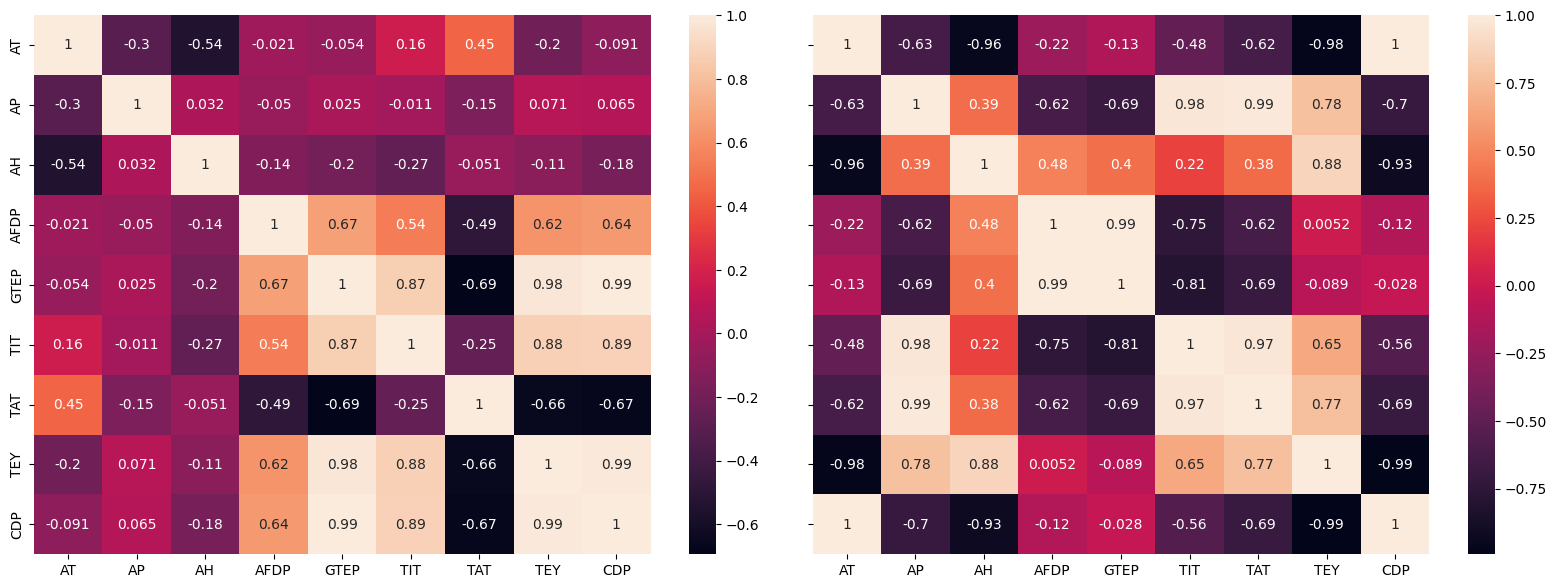

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)
fig.set_size_inches(20, 7, forward=True)
fig.subplots_adjust(wspace=0.01)

sns.heatmap(train_dataset.df.corr(), annot=True, ax=axes[0])
sns.heatmap(df_generated.corr(), annot=True, ax=axes[1])

plt.show()